# **Data Manipulation and Outliers Handling**

**importing pandas,numpy,matplotlib,seaborn**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**mounting**

In [6]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [28]:
df = pd.read_csv("/content/drive/MyDrive/dsml/new_titanic.csv")
df.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


**Inserting and Deleting columns and rows**

Deleting pid column

In [29]:
df.drop("PassengerId",axis = 1, inplace = True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Deleting rows**

In [30]:
df.drop([0],axis = 0,inplace = True)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q


**Inserting a column**

In [34]:
last_names = [name.split(",")[0] for name in df["Name"]]
df["last_name"] = last_names
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,last_name
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen
5,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Moran


In [39]:
df["total_cost"] = df.apply(
    lambda row: row["Fare"] * row["SibSp"] if row["SibSp"] != 0 else row["Fare"],
    axis=1
)

df.head()


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,last_name,total_cost
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,71.2833
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,7.9250
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,53.1000
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,8.0500
5,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Moran,8.4583


**Inserting a row**

In [44]:
df.loc[900,:] = [0,3,"Magar, Gaurav","male",23.0,21,0," A5 3122",7.95,np.nan,"S","Magar",7.9250]
df.tail()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,last_name,total_cost
887,1.0,1.0,"Graham, Miss. Margaret Edith",female,19.0,0.0,0.0,112053,30.00,B42,S,Graham,30.000
888,0.0,3.0,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1.0,2.0,W./C. 6607,23.45,NaN,S,Johnston,23.450
889,1.0,1.0,"Behr, Mr. Karl Howell",male,26.0,0.0,0.0,111369,30.00,C148,C,Behr,30.000
890,0.0,3.0,"Dooley, Mr. Patrick",male,32.0,0.0,0.0,370376,7.75,NaN,Q,Dooley,7.750
900,0.0,3.0,"Magar, Gaurav",male,23.0,21.0,0.0,A5 3122,7.95,NaN,S,Magar,7.925


In [56]:
del_name = input("Enter the last name of user whose detail you want to delete: ").strip().title()
index = np.where(df["last_name"] == del_name)[0]
df.drop(df.index[index],axis = 0, inplace = True)
df.tail()

Enter the last name of user whose detail you want to delete: Magar


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,last_name,total_cost
882,0.0,3.0,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0.0,0.0,7552,10.5167,NaN,S,Dahlberg,10.5167
883,0.0,2.0,"Banfield, Mr. Frederick James",male,28.0,0.0,0.0,C.A./SOTON 34068,10.5000,NaN,S,Banfield,10.5000
884,0.0,3.0,"Sutehall, Mr. Henry Jr",male,25.0,0.0,0.0,SOTON/OQ 392076,7.0500,NaN,S,Sutehall,7.0500
885,0.0,3.0,"Rice, Mrs. William (Margaret Norton)",female,39.0,0.0,5.0,382652,29.1250,NaN,Q,Rice,29.1250
886,0.0,2.0,"Montvila, Rev. Juozas",male,27.0,0.0,0.0,211536,13.0000,NaN,S,Montvila,13.0000


**Handling null values**

In [57]:
df.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,176
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,684


**removing null values**

In [61]:
print("Before dropping null values:",df.shape)
df_filter = df.dropna(subset = "Embarked",axis = 0,how = "all",ignore_index = True)
print("After dropping null values:",df_filter.shape)

Before dropping null values: (886, 13)
After dropping null values: (884, 13)


In [65]:
df_filter = df.dropna(subset=["Age","Cabin","Embarked"],axis = 0, how = "any",ignore_index = True)
print("Shape:" ,df_filter.shape)
print(df_filter.isnull().sum())

Shape: (181, 13)
Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin         0
Embarked      0
last_name     0
total_cost    0
dtype: int64


In [66]:
df_filter

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,last_name,total_cost
0,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,C85,C,Cumings,71.2833
1,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,C123,S,Futrelle,53.1000
2,0.0,1.0,"McCarthy, Mr. Timothy J",male,54.0,0.0,0.0,17463,51.8625,E46,S,McCarthy,51.8625
3,1.0,3.0,"Sandstrom, Miss. Marguerite Rut",female,4.0,1.0,1.0,PP 9549,16.7000,G6,S,Sandstrom,16.7000
4,1.0,1.0,"Bonnell, Miss. Elizabeth",female,58.0,0.0,0.0,113783,26.5500,C103,S,Bonnell,26.5500
...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,1.0,1.0,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",female,48.0,0.0,0.0,17466,25.9292,D17,S,Swift,25.9292
177,0.0,1.0,"Roebling, Mr. Washington Augustus II",male,31.0,0.0,0.0,PC 17590,50.4958,A24,S,Roebling,50.4958
178,1.0,1.0,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1.0,1.0,11751,52.5542,D35,S,Beckwith,52.5542
179,0.0,1.0,"Carlsson, Mr. Frans Olof",male,33.0,0.0,0.0,695,5.0000,B51 B53 B55,S,Carlsson,5.0000


**Replacing null values with mean**

**Also called: Imputation of age**

29.726999999999997


<Axes: ylabel='Frequency'>

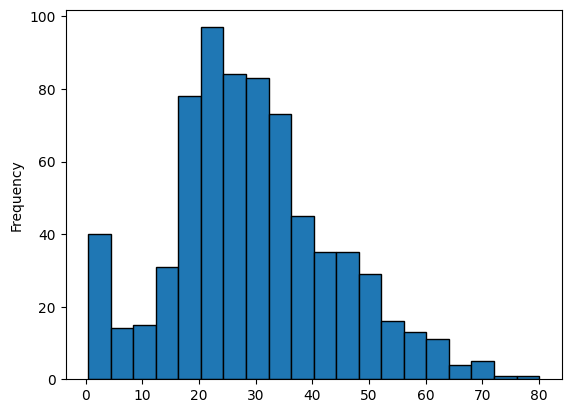

In [71]:
print(df.Age.mean())
df.Age.plot.hist(bins = 20,edgecolor ="black")

In [82]:
new_df = df
print("From here:\n",new_df.isnull().sum())
mean_age = df.Age.mean()
new_df["Age"]= new_df["Age"].fillna(mean_age,axis = 0)
print("From here:\n",new_df.isnull().sum())

From here:
 Survived        0
Pclass          0
Name            0
Sex             0
Age             0
SibSp           0
Parch           0
Ticket          0
Fare            0
Cabin         684
Embarked        2
last_name       0
total_cost      0
dtype: int64
From here:
 Survived        0
Pclass          0
Name            0
Sex             0
Age             0
SibSp           0
Parch           0
Ticket          0
Fare            0
Cabin         684
Embarked        2
last_name       0
total_cost      0
dtype: int64


<Axes: ylabel='Frequency'>

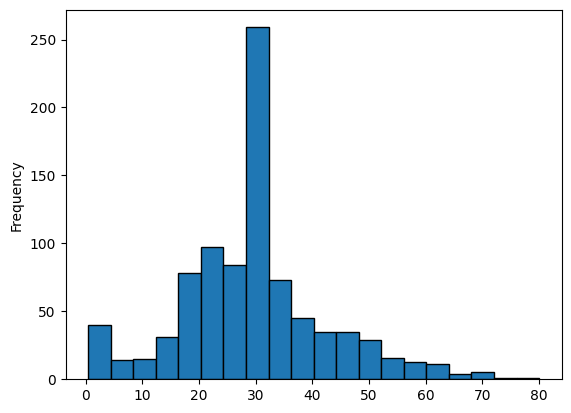

In [84]:
new_df.Age.plot.hist(bins = 20,edgecolor = "black")

In [85]:
titanic_df = pd.read_csv("/content/drive/MyDrive/dsml/new_titanic.csv")

In [88]:

titanic_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [90]:
mean_ages = titanic_df.groupby("Sex")["Age"].transform("mean")
print(mean_ages)

29.69911764705882
0      30.726645
1      27.915709
2      27.915709
3      27.915709
4      30.726645
         ...    
886    30.726645
887    27.915709
888    27.915709
889    30.726645
890    30.726645
Name: Age, Length: 891, dtype: float64


In [92]:
titanic_df["Age"].fillna(mean_ages,inplace = True)
titanic_df["Age"]

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,27.915709
889,26.000000


**Simple Example of how transform works**

In [93]:
df = pd.DataFrame({
    "Store": ["A","A","B","B","B"],
    "Sales" : [100,200,150,250,500]
})
df["Store_mean_sales"] = df.groupby("Store")["Sales"].transform("mean")
df

,Store,Sales,Store_mean_sales
0,A,100,150.0
1,A,200,150.0
2,B,150,300.0
3,B,250,300.0
4,B,500,300.0


**Features of null values**

In [94]:
titanic_df.Cabin

,Cabin
0,NaN
1,C85
2,NaN
3,C123
4,NaN
...,...
886,NaN
887,B42
888,NaN
889,C148


**Converting Cabin into int data type**

- **if NaN it will be 0 else 1 (so the count of null value will be 0)**

In [95]:
titanic_df.Cabin = titanic_df["Cabin"].notna().astype(int)
titanic_df.Cabin.dtype

dtype('int64')

In [101]:
titanic_df["Cabin"].head(5)

,Cabin
0,0
1,1
2,0
3,1
4,0


In [96]:
titanic_df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: title={'center': 'Box Plot of passengers age'}>

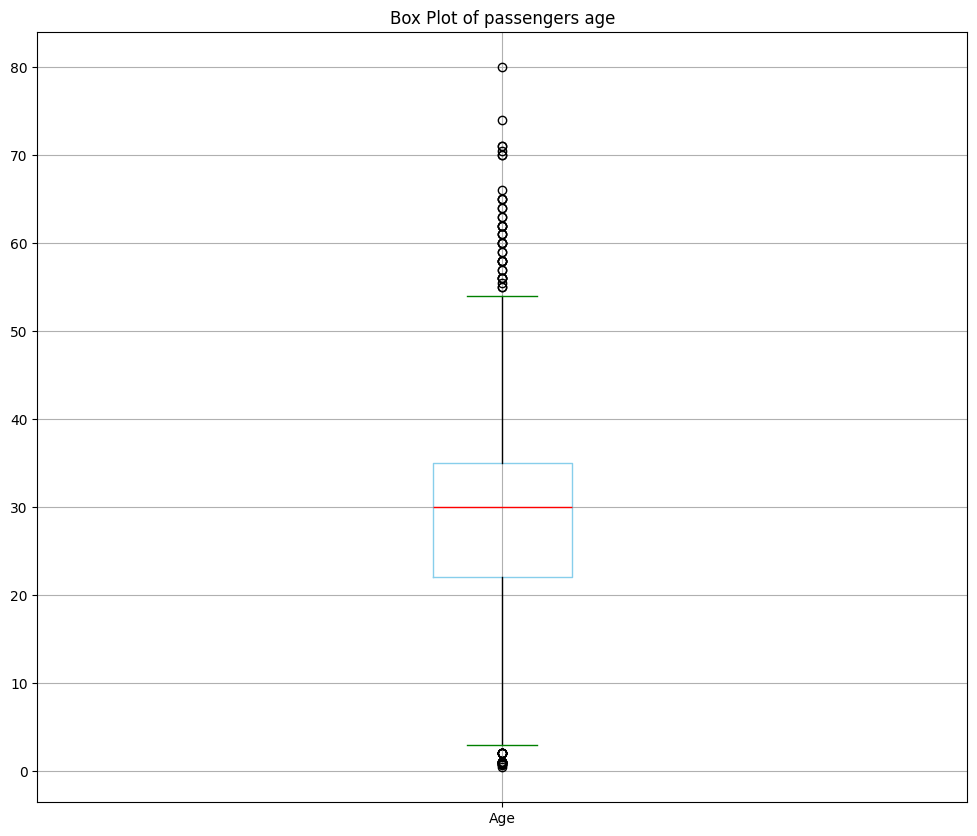

In [100]:
titanic_df.Age.plot.box(
    figsize = (12,10),
    title = "Box Plot of passengers age",
    grid = True,
    color={
        "boxes": "skyblue",
        "whiskers": "black",
        "medians": "red",
        "caps": "green"
    }
)

**Handling Null values for age using initials (Mr.,Miss. or Master) groups**

In [103]:
titles = titanic_df["Name"].str.split(",")
titanic_df["Title"] = titles.str[1].str.strip().str.split(" ").str[0]
titanic_df.loc[886]

,886
PassengerId,887
Survived,0
Pclass,2
Name,"Montvila, Rev. Juozas"
Sex,male
Age,27.0
SibSp,0
Parch,0
Ticket,211536
Fare,13.0


**print all the duplicates**

In [104]:
titanic_df[titanic_df.duplicated(subset = "Name")]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title


**dropping all the duplicate values**

In [107]:
titanic_df.drop_duplicates(inplace = True)

In [111]:
new_df = titanic_df
new_df[new_df.duplicated(subset = "Sex")]
new_df["Sex"].drop_duplicates().head()

,Sex
0,male
1,female
